In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
nav_df = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

scorecard_df = pd.read_csv("../data/processed/fund_scorecard.csv")

scheme_df = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

investor_df = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")

portfolio_df = pd.read_csv("../data/processed/09_portfolio_holdings.csv")

In [3]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

nav_df = nav_df.sort_values(["amfi_code", "date"])

nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
    .pct_change()
)

nav_df.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [4]:
var_report = (
    nav_df.groupby("amfi_code")["daily_return"]
    .quantile(0.05)
    .reset_index()
)

var_report.rename(
    columns={"daily_return":"VaR_95"},
    inplace=True
)

var_report.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [5]:
cvar_list = []

for fund in nav_df["amfi_code"].unique():

    temp = nav_df[nav_df["amfi_code"] == fund]

    var95 = temp["daily_return"].quantile(0.05)

    cvar95 = temp[temp["daily_return"] <= var95]["daily_return"].mean()

    cvar_list.append([fund, cvar95])

cvar_df = pd.DataFrame(
    cvar_list,
    columns=["amfi_code", "CVaR_95"]
)

cvar_df.head()

,amfi_code,CVaR_95
0,100016,-0.018060
1,100025,-0.004994
2,100033,-0.023456
3,101206,-0.017439
4,101207,-0.032459


In [6]:
risk_report = var_report.merge(
    cvar_df,
    on="amfi_code"
)

risk_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [7]:
returns_df = nav_df.copy()

returns_df["rolling_mean"] = (
    returns_df.groupby("amfi_code")["daily_return"]
    .transform(lambda x: x.rolling(90).mean())
)

returns_df["rolling_std"] = (
    returns_df.groupby("amfi_code")["daily_return"]
    .transform(lambda x: x.rolling(90).std())
)

returns_df["rolling_sharpe"] = (
    returns_df["rolling_mean"] /
    returns_df["rolling_std"]
) * np.sqrt(252)

returns_df.head()

,amfi_code,date,nav,daily_return,rolling_mean,rolling_std,rolling_sharpe
0,100016,2022-01-03,520.4608,NaN,NaN,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN,NaN,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN,NaN,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN,NaN,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN,NaN,NaN


In [8]:
top5_funds = scorecard_df.head(5)["amfi_code"]

top5_funds

0    120505
1    119598
2    149324
3    148569
4    148567
Name: amfi_code, dtype: int64

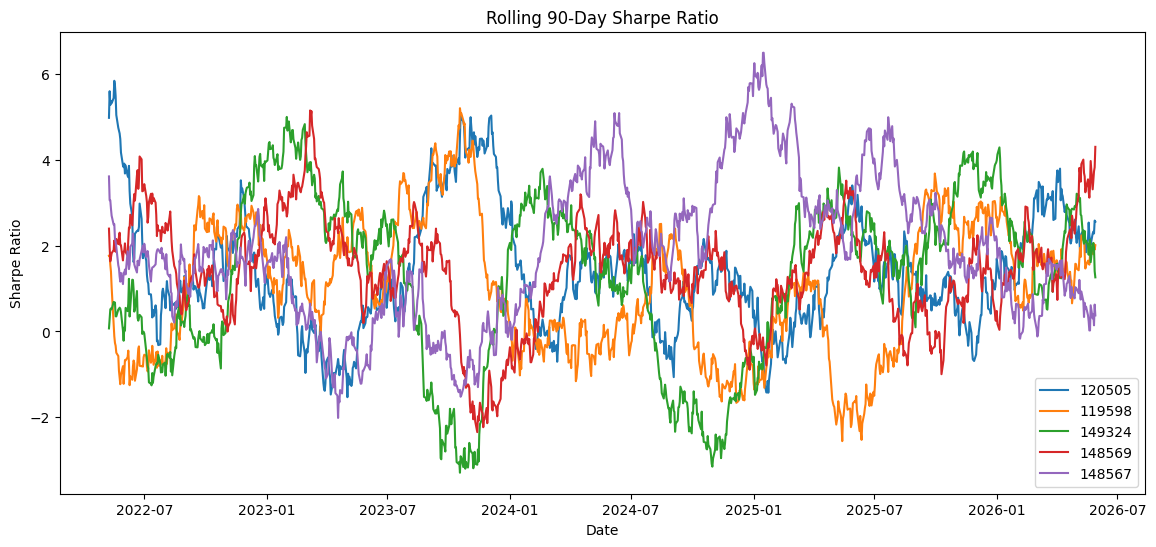

In [9]:
plt.figure(figsize=(14,6))

for fund in top5_funds:

    temp = returns_df[
        returns_df["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()

plt.show()

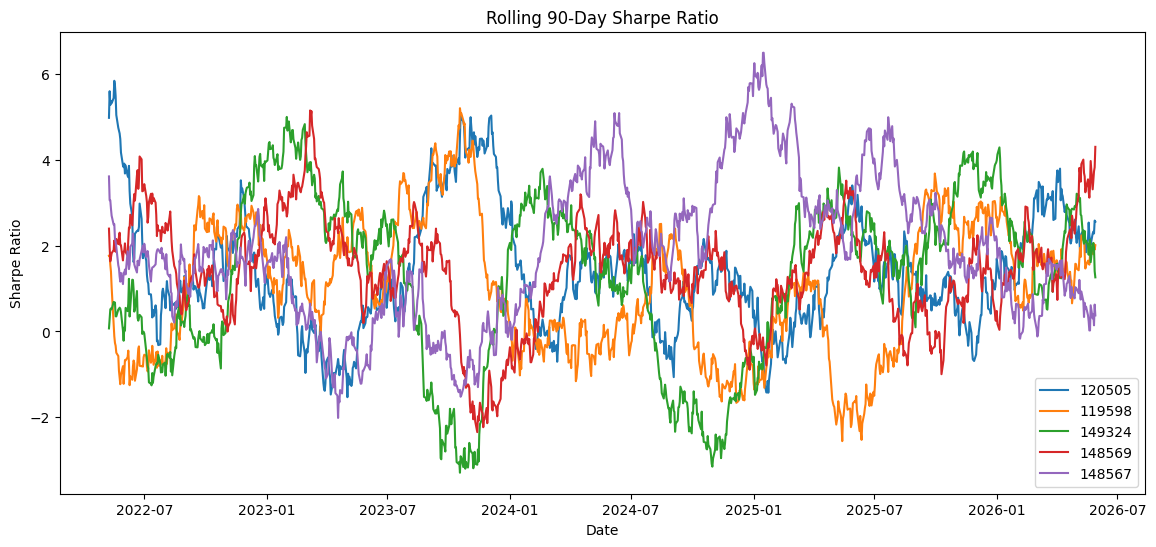

In [10]:
plt.figure(figsize=(14,6))

for fund in top5_funds:

    temp = returns_df[
        returns_df["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()

plt.savefig(
    "rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
investor_df["transaction_date"] = pd.to_datetime(investor_df["transaction_date"])

investor_df["cohort_year"] = investor_df.groupby("investor_id")["transaction_date"].transform("min").dt.year

cohort_analysis = investor_df.groupby("cohort_year").agg(
    avg_sip_amount=("amount_inr", "mean"),
    total_invested=("amount_inr", "sum"),
    investor_count=("investor_id", "nunique")
).reset_index()

cohort_analysis

,cohort_year,avg_sip_amount,total_invested,investor_count
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [12]:
risk_report.to_csv("../data/processed/var_cvar_report.csv", index=False)

print("var_cvar_report.csv saved successfully!")

var_cvar_report.csv saved successfully!


In [13]:
sip_df = investor_df[investor_df["transaction_type"] == "SIP"].copy()

sip_df = sip_df.sort_values(
    ["investor_id", "transaction_date"]
)

sip_df["gap_days"] = (
    sip_df.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_continuity = (
    sip_df.groupby("investor_id")
    .agg(
        avg_gap_days=("gap_days", "mean"),
        transaction_count=("transaction_date", "count")
    )
    .reset_index()
)

sip_continuity["status"] = np.where(
    sip_continuity["avg_gap_days"] > 35,
    "At Risk",
    "Normal"
)

sip_continuity.head()

,investor_id,avg_gap_days,transaction_count,status


In [14]:
scheme_df[["amfi_code", "risk_grade"]].head()

,amfi_code,risk_grade
0,119551,Moderate
1,119552,Moderate
2,119598,Very High
3,119599,Very High
4,119120,Low


In [15]:
scheme_df.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

In [16]:
user_risk = "Moderate"

recommendations = (
    scheme_df[
        scheme_df["risk_grade"] == user_risk
    ]
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    [["amfi_code",
      "scheme_name",
      "sharpe_ratio",
      "risk_grade"]]
    .head(3)
)

recommendations

,amfi_code,scheme_name,sharpe_ratio,risk_grade
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,1.06,Moderate
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.06,Moderate
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.03,Moderate


In [17]:
recommendations.to_csv(
    "../data/processed/recommendations.csv",
    index=False
)

print("Recommendations saved successfully!")

Recommendations saved successfully!


# Advanced Insights

1. Funds with highly negative VaR values indicate higher downside risk.

2. CVaR values show the average loss beyond the VaR threshold.

3. Rolling 90-day Sharpe ratio helps analyze changing risk-adjusted performance over time.

4. Investor cohorts with higher invested amounts contribute significantly to overall growth.

5. Moderate-risk funds with high Sharpe ratios provide suitable investment opportunities for balanced investors.